In [1]:
import yaml
import jax.numpy as jnp
from ajx import Transform
from panda3d.core import loadPrcFileData
from ajx.example_environments.locked_dlo import LockedDLO

loadPrcFileData("", "window-type offscreen")
loadPrcFileData("", "win-size 640 480")

import numpy as np
from PIL import Image
from IPython.display import display

import jax

jax.config.update("jax_enable_x64", True)

from ajx.example_graphics.environment_scene import EnvironmentScene
from ajx.example_graphics.application import Application
from ajx.constraints import ConstraintType
from ajx.example_environments.dlo import DLO, DLOSettings, CableParameters#, LockedDLO
from ajx.simulation import SimulationSettings, Solver
import jax.numpy as jnp
import ajx.math as math
from ajx import Transform

#print(dir(DLO))




An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [5]:
timestep = 1/60
grippermc_to_marker = jnp.array([0.0478024, 0, 0])

states = []
with open("marker_data/simulated_dlo_marker_data.yaml", "r") as stream:
    data_loaded = yaml.safe_load(stream)

gripper_com_to_marker = jnp.array(data_loaded["gripper_com_to_marker"])
env = LockedDLO(
    sim_settings=SimulationSettings(timestep, True, Solver.DENSE_LINEAR),
    env_settings=DLOSettings.create(
        n_segments=50,
        length=data_loaded["length"],
        radius=data_loaded["radius"],
        density=data_loaded["mass"] / (data_loaded["length"]*data_loaded["radius"]**2*np.pi),
        pose_estimate_linear_offsets=data_loaded["marker_displacements"],
        gripper1_offset=Transform(gripper_com_to_marker, math.Rotations.unitary),
        gripper2_offset=Transform(-gripper_com_to_marker, math.Rotations.unitary),
        loose_end=False,
    ),
)

nu = 0.333
E = 1e7
cable_param = CableParameters(
    youngs_modulus=E,
    shear_modulus=E / (2 * (1 + nu)),
    damping=env.default_param.sparse_param.cable_param.damping,
)

env_param = env.default_param.tree_replace(
    src={"sparse_param.cable_param": cable_param}
)

for sample_name, marker_pose in data_loaded["marker_poses"].items():

    # 1. build marker transforms for THIS frame
    marker_transform_list = []
    for site_name, pose in marker_pose.items():
        marker_transform_list.append(
            Transform(
                jnp.array(pose["pos"]),
                jnp.array(pose["rot"])
            )
        )

    marker_transforms = Transform.stack(marker_transform_list)

    # 2. convert to body + frame
    body_transforms = env.convert_marker_transforms_to_body_transforms(marker_transforms)

    frame_transforms = env.convert_body_transforms_to_frame_transforms(
        env_param, body_transforms
    )

    # 3. build state
    state = env.get_state_by_interface_interpolation(
        env_param,
        [frame_transforms[0], frame_transforms[1], body_transforms]
    )

    # 4. store it
    states.append(state)

state0 = states[0]


print("num segments:", state0.conf.pos.shape[0])
print("first segment:", state0.conf.pos[0])
print("last segment:", state0.conf.pos[-1])
print(len(states))







#recreate state from data

sample_name = list(data_loaded["marker_poses"].keys())[0] #Initial poses or first at least
marker_pose = data_loaded["marker_poses"][sample_name]

num segments: 52
first segment: [-2.00000562e-01  0.00000000e+00 -3.33115755e-07]
last segment: [ 2.00000562e-01  0.00000000e+00 -3.33084339e-07]
4


Known pipe types:
  glxGraphicsPipe
(1 aux display modules not yet loaded.)
Xlib:  extension "XFree86-DGA" missing on display ":0".
AL lib: (EE) ALCplaybackOSS_open: Could not open /dev/dsp: No such file or directory
AL lib: (WW) alcSetError: Error generated on device (nil), code 0xa004
AL lib: (EE) ALCplaybackOSS_open: Could not open /dev/dsp: No such file or directory
AL lib: (WW) alcSetError: Error generated on device (nil), code 0xa004
:audio(error): Couldn't open default OpenAL device
:audio(error): OpenALAudioManager: No open device or context
:audio(error):   OpenALAudioManager is not valid, will use NullAudioManager
AL lib: (EE) ALCplaybackOSS_open: Could not open /dev/dsp: No such file or directory
AL lib: (WW) alcSetError: Error generated on device (nil), code 0xa004
AL lib: (EE) ALCplaybackOSS_open: Could not open /dev/dsp: No such file or directory
AL lib: (WW) alcSetError: Error generated on device (nil), code 0xa004
:audio(error): Couldn't open default OpenAL device
:audi

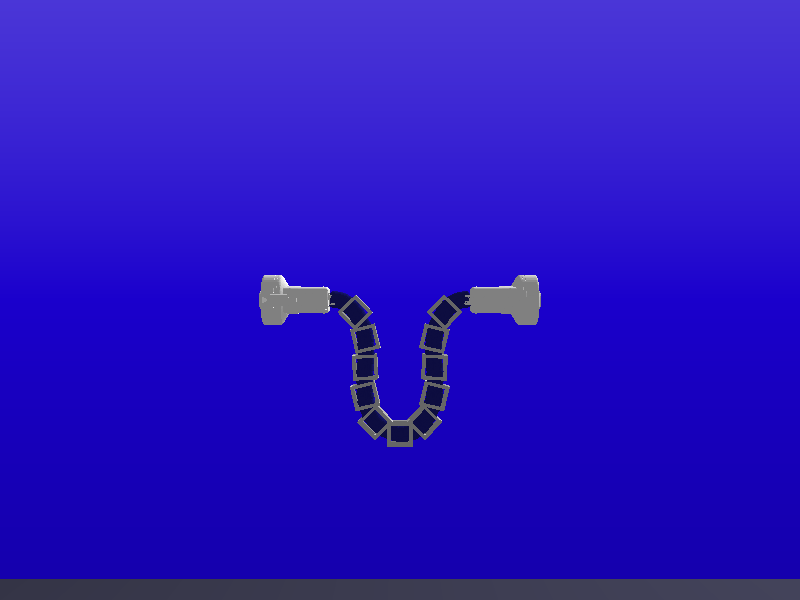

In [6]:
env.camera_rot = math.quat_from_axis_angle(jnp.array([0.0, 0.0, 1.0]), jnp.pi)
scene = EnvironmentScene(env, env_param, states[0], show_text=False, show_fps=False, debug_render=False)
# 1. kill old app safely
try:
    app.destroy()
except:
    pass
    
try:
    del scene
except:
    pass

# 2. rebuild scene from scratch
scene = EnvironmentScene(env, env_param, states[0],
                         show_text=False,
                         show_fps=False,
                         debug_render=False)


# 3. create fresh app
app = Application(scene, 60, "default", headless=True)

# 4. render
scene.update_geometry()
img = app.get_headless_frame()
display(img)

In [7]:
import imageio
from IPython.display import Video

writer = imageio.get_writer("animation.mp4", fps=5)  # slower since only 9 frames

frames = []

for state in states:
    scene.state = state
    scene.update_geometry()

    app.graphicsEngine.renderFrame()
    frame = app.get_headless_frame()

    writer.append_data(np.array(frame))

writer.close()

Video("animation.mp4")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [12]:
from ajx.tree_util import tangent_jacfwd
from ajx.definitions import State, GeneralizedVelocity
from ajx.example_environments.dlo import DLOState

state_ini = states[0]
target_pose = state_ini.conf
lock_targets = state_ini.lock_targets
start_err = jnp.linalg.norm(state.gvel.data)
n_bodies = env.default_param.rigid_body_param.mass.shape[0]

def forward_dynamics_residual(param):
    gvel = GeneralizedVelocity(jnp.zeros([n_bodies, 6]))
    state = DLOState(target_pose, gvel, lock_targets)
    next_state = env.step_state(state, jnp.zeros([12]), param)
    return next_state.gvel.data.flatten()

def inverse_dynamics_residual(param):
    gvel = GeneralizedVelocity(jnp.zeros([n_bodies, 6]))
    state = DLOState(target_pose, gvel, lock_targets)
    force = env.sim.inverse_dynamics(state, gvel, jnp.zeros([12]), param)
    return force.flatten()

def forward_dynamics_residual_multi_states(param):
    residuals = []

    for s in states:
        target_pose = s.conf
        lock_targets = s.lock_targets

        gvel = GeneralizedVelocity(jnp.zeros([n_bodies, 6]))
        state = DLOState(target_pose, gvel, lock_targets)

        next_state = env.step_state(state, jnp.zeros([12]), param)

        residuals.append(next_state.gvel.data.flatten())

    return jnp.concatenate(residuals)

def forward_dynamics_residual_multi_states(param):
    residuals = []

    for s in states:
        target_pose = s.conf
        lock_targets = s.lock_targets

        gvel = GeneralizedVelocity(jnp.zeros([n_bodies, 6]))
        state = DLOState(target_pose, gvel, lock_targets)

        next_state = env.step_state(state, jnp.zeros([12]), param)

        residuals.append(next_state.gvel.data.flatten())

    return jnp.concatenate(residuals)

residual = forward_dynamics_residual_multi_states
jac_r = tangent_jacfwd(residual)

def gauss_newton(x0, max_iter, damping, tol):
    x = x0
    for i in range(max_iter):
        rx = residual(x)  
        J = jac_r(x) 
        if jnp.linalg.norm(rx)**2 < tol:
            return x, J

        # Gauss-Newton step: solve (J^T J) delta = -J^T r
        JTJ = J.T @ J + jnp.eye(J.shape[1]) * damping
        JTr = J.T @ rx
        delta = -jnp.linalg.solve(JTJ, JTr)

        x = x.retract(delta)
        print(f"Iter: {i}\t |rx|: {jnp.linalg.norm(rx)} E: {x.sparse_param.cable_param.youngs_modulus} G: {x.sparse_param.cable_param.shear_modulus}")
        #singular value decomp for debug
        u, s, vh = jnp.linalg.svd(J)
        print(s)
    return x, J


# Pretend that stiffness is unknown
env_param = env.default_param.tree_replace(src={
    "sparse_param.cable_param.youngs_modulus":  1e5,
    "sparse_param.cable_param.shear_modulus":  1e5,
})

# Set stiffness as tunable
env_param = env_param.replace(
    tangent_restrictions=(
        "sparse_param.cable_param.youngs_modulus",
        "sparse_param.cable_param.shear_modulus",
    )
)

# Optimize
solution, Js = gauss_newton(env_param, max_iter=200, damping=0.0, tol = 1e-12)
print(jnp.linalg.cond(Js))
print(solution.sparse_param.cable_param.youngs_modulus)
print(solution.sparse_param.cable_param.shear_modulus)







Iter: 0	 |rx|: 54.19279869381144 E: 274389.9662810556 G: 187178.75276888677
[4.48613353e-04 5.12675549e-05]
Iter: 1	 |rx|: 49.88931561490204 E: 623795.7209653932 G: 341865.13193431345
[2.06847271e-04 2.24773858e-05]
Iter: 2	 |rx|: 48.11679644181167 E: 813569.615642258 G: 370531.53695140086
[1.04456357e-04 1.23063702e-05]
Iter: 3	 |rx|: 47.64443039773443 E: 811035.5039366505 G: 352697.7183941316
[8.61144195e-05 1.00240348e-05]
Iter: 4	 |rx|: 47.62573858330174 E: 814027.8830140379 G: 353934.5193473352
[8.74967399e-05 1.00563369e-05]
Iter: 5	 |rx|: 47.62573037846549 E: 813242.327642723 G: 353608.87696016143
[8.72078476e-05 1.00266667e-05]
Iter: 6	 |rx|: 47.62572981654966 E: 813449.8166094995 G: 353694.81856277975
[8.72835652e-05 1.00344386e-05]
Iter: 7	 |rx|: 47.62572977725095 E: 813395.1003894886 G: 353672.15052516566
[8.72635577e-05 1.00323847e-05]
Iter: 8	 |rx|: 47.62572977453091 E: 813409.5355162842 G: 353678.13043570373
[8.72688333e-05 1.00329262e-05]
Iter: 9	 |rx|: 47.62572977433061

In [20]:
# Print results
youngs_modulus = solution.sparse_param.cable_param.youngs_modulus
shear_modulus = solution.sparse_param.cable_param.shear_modulus
poissons_ratio = youngs_modulus / (2 * shear_modulus) - 1
print(f"Poisson's ratio: {poissons_ratio}")
print(
    f"Youngs modulus, shear modulus: \t{youngs_modulus}, {shear_modulus}"
)

# Estimate uncertainty
U, S, V = jnp.linalg.svd(Js)

JTJ_inv = V @ jnp.diag((1/(S+1e-16))**2) @ V.T
residual_sample_variance = jnp.linalg.norm(residual(solution))**2 / (residual(solution).shape[0] - env_param.tangent_size())
cov = JTJ_inv * residual_sample_variance
parameter_std = jnp.sqrt(jnp.diag(cov))
print(f"Standard deviation estimate: \t\t{parameter_std[:3]}")

Poisson's ratio: 0.33299884346610464
Youngs modulus, shear modulus: 	9999990.188833857, 3750937.3087044754
Standard deviation estimate: 		[ 2.95491017 14.66724994]


Marker error: 1.988765008579603e-32


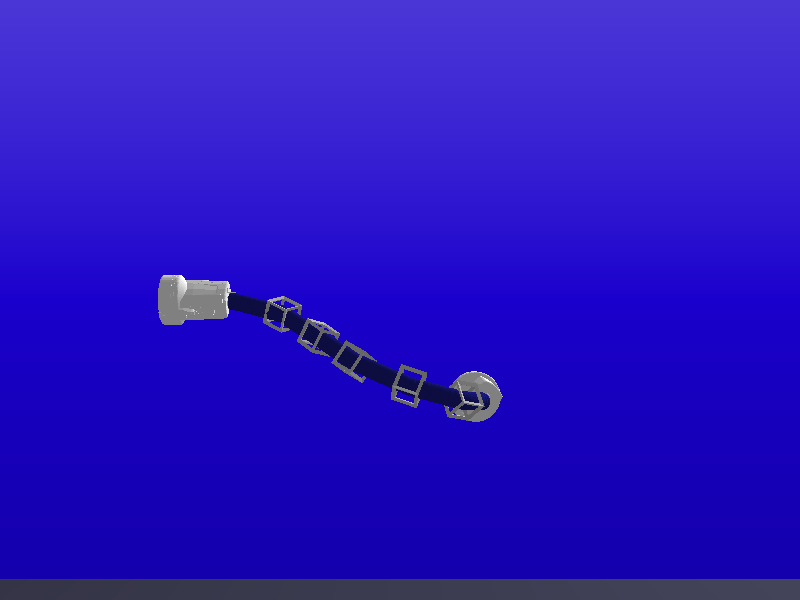

In [21]:
n_confs = len(observations)
marker_transforms = Transform(
    observations.reshape(-1,7)[:,:3],
    observations.reshape(-1,7)[:,3:],
)
concat_pose = jnp.stack(observations)

body_transforms = env.convert_marker_transforms_to_body_transforms(
    marker_transforms
)
frame_transforms = env.convert_body_transforms_to_frame_transforms(
    env_param, body_transforms
)
state = env.get_state_by_interface_interpolation(
    env_param, [frame_transforms[0], frame_transforms[1], body_transforms]
)

# Ensure the state is aligned with the marker poses
n_poses = len(env.sim.sensor_list)
observed_marker_poses_flat = env.observe_state(state, jnp.zeros(12), env_param)
observed_marker_poses_arr = observed_marker_poses_flat.reshape(n_poses, 7)
observed_marker_poses = Transform(observed_marker_poses_arr[:,:3], observed_marker_poses_arr[:,3:])
marker_residual = jax.vmap(Transform.log_map)(observed_marker_poses, marker_transforms)
squared_error = jnp.sum(marker_residual**2)
print(f"Marker error: {squared_error}")

scene.state = state
scene.update_geometry()
img = app.get_headless_frame()
display(img)